In [1]:
from experiments.rag_exp import *

/home/yuri/HSE/ВКР/RAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Подготовка данных

In [2]:
docs = load_and_prepare_docs("./data")
page_mapper = PageMapper(docs)
splitter_factory = SplitterFactory("intfloat/multilingual-e5-large-instruct")
eval_data = EvalDataLoader.load(
    "./context/docs_questions_qwen3_14b_awq.jsonl",
    skip_pages={72,73,74,75,76,77,78,79,80,81}
)

2026-04-25 11:06:20,984 - INFO - Пустые страницы: [34, 86]
2026-04-25 11:06:20,984 - INFO - Загружено 84 непустых страниц
2026-04-25 11:06:22,827 - INFO - Токенизатор: intfloat/multilingual-e5-large-instruct
2026-04-25 11:06:22,828 - INFO - Загружено 222 вопросов из ./context/docs_questions_qwen3_14b_awq.jsonl


### Эксперимент 1. Подбор chunk size

2026-04-24 17:13:33,636 - INFO - ============================================================
Эксперимент: token_150_75
2026-04-24 17:13:33,636 - INFO - CREATE COLLECTION
2026-04-24 17:13:33,638 - INFO - wb_token_150_75 уже существует, пропускаем
2026-04-24 17:13:34,450 - INFO -   token_150_75 | k= 1 | P=0.644 R=0.644 F1=0.644 HR=0.644 MRR=0.644
2026-04-24 17:13:34,451 - INFO -   token_150_75 | k= 2 | P=0.563 R=0.743 F1=0.623 HR=0.743 MRR=0.694
2026-04-24 17:13:34,453 - INFO -   token_150_75 | k= 3 | P=0.501 R=0.779 F1=0.587 HR=0.779 MRR=0.706
2026-04-24 17:13:34,454 - INFO -   token_150_75 | k= 5 | P=0.428 R=0.856 F1=0.540 HR=0.856 MRR=0.724
2026-04-24 17:13:34,456 - INFO -   token_150_75 | k=10 | P=0.332 R=0.928 F1=0.465 HR=0.928 MRR=0.734
2026-04-24 17:13:34,457 - INFO - ============================================================
Эксперимент: token_328_75
2026-04-24 17:13:34,457 - INFO - CREATE COLLECTION
2026-04-24 17:13:34,459 - INFO - wb_token_328_75 уже существует, пропускаем
2

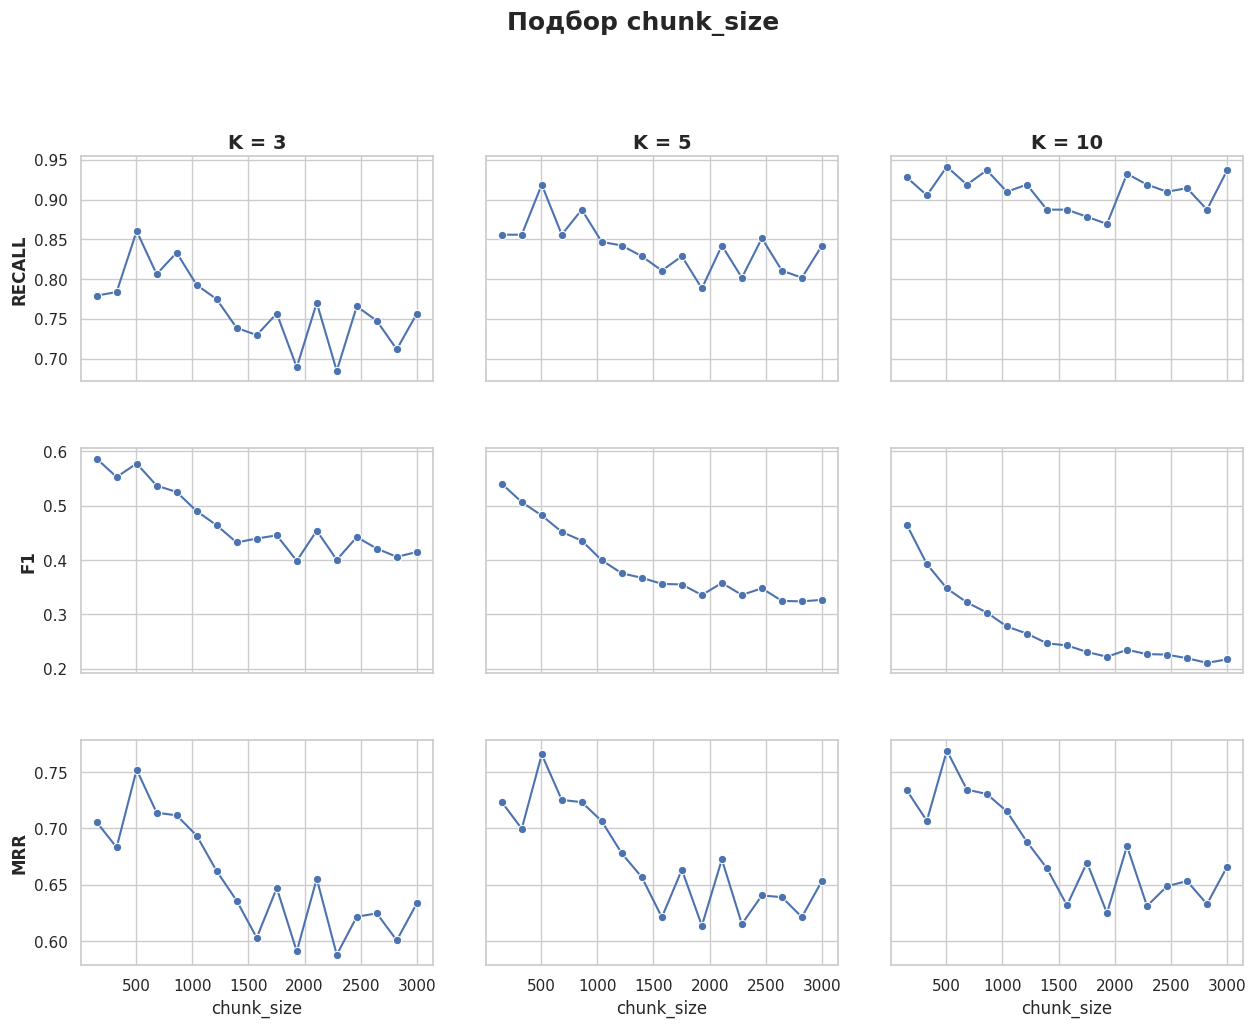

In [4]:
configs_cs = [
    RAGConfig(name=f"token_{cs}_75", chunking=ChunkingConfig(chunk_size=cs, chunk_overlap=75), recreate=False)
    for cs in np.linspace(150, 3000, 17, dtype=int)
]
results_cs = await run_experiments(configs_cs, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/chunk_size.csv")
ResultsVisualizer.plot_by_variable(results_cs, x_col="chunk_size", title="Подбор chunk_size",save_path="./new_results/chunk_size.png", k_values=[3,5,10])

### Эксперимент 2. Подбор Overlap

2026-04-24 17:25:46,508 - INFO - ============================================================
Эксперимент: token_506_50
2026-04-24 17:25:46,508 - INFO - CREATE COLLECTION
2026-04-24 17:25:46,510 - INFO - wb_token_506_50 уже существует, пропускаем
2026-04-24 17:25:47,340 - INFO -   token_506_50 | k= 1 | P=0.631 R=0.631 F1=0.631 HR=0.631 MRR=0.631
2026-04-24 17:25:47,342 - INFO -   token_506_50 | k= 2 | P=0.520 R=0.748 F1=0.596 HR=0.748 MRR=0.689
2026-04-24 17:25:47,343 - INFO -   token_506_50 | k= 3 | P=0.446 R=0.806 F1=0.552 HR=0.806 MRR=0.709
2026-04-24 17:25:47,345 - INFO -   token_506_50 | k= 5 | P=0.341 R=0.860 F1=0.469 HR=0.860 MRR=0.721
2026-04-24 17:25:47,347 - INFO -   token_506_50 | k=10 | P=0.210 R=0.905 F1=0.330 HR=0.905 MRR=0.727
2026-04-24 17:25:47,347 - INFO - ============================================================
Эксперимент: token_506_75
2026-04-24 17:25:47,347 - INFO - CREATE COLLECTION
2026-04-24 17:25:47,349 - INFO - wb_token_506_75 уже существует, пропускаем
2

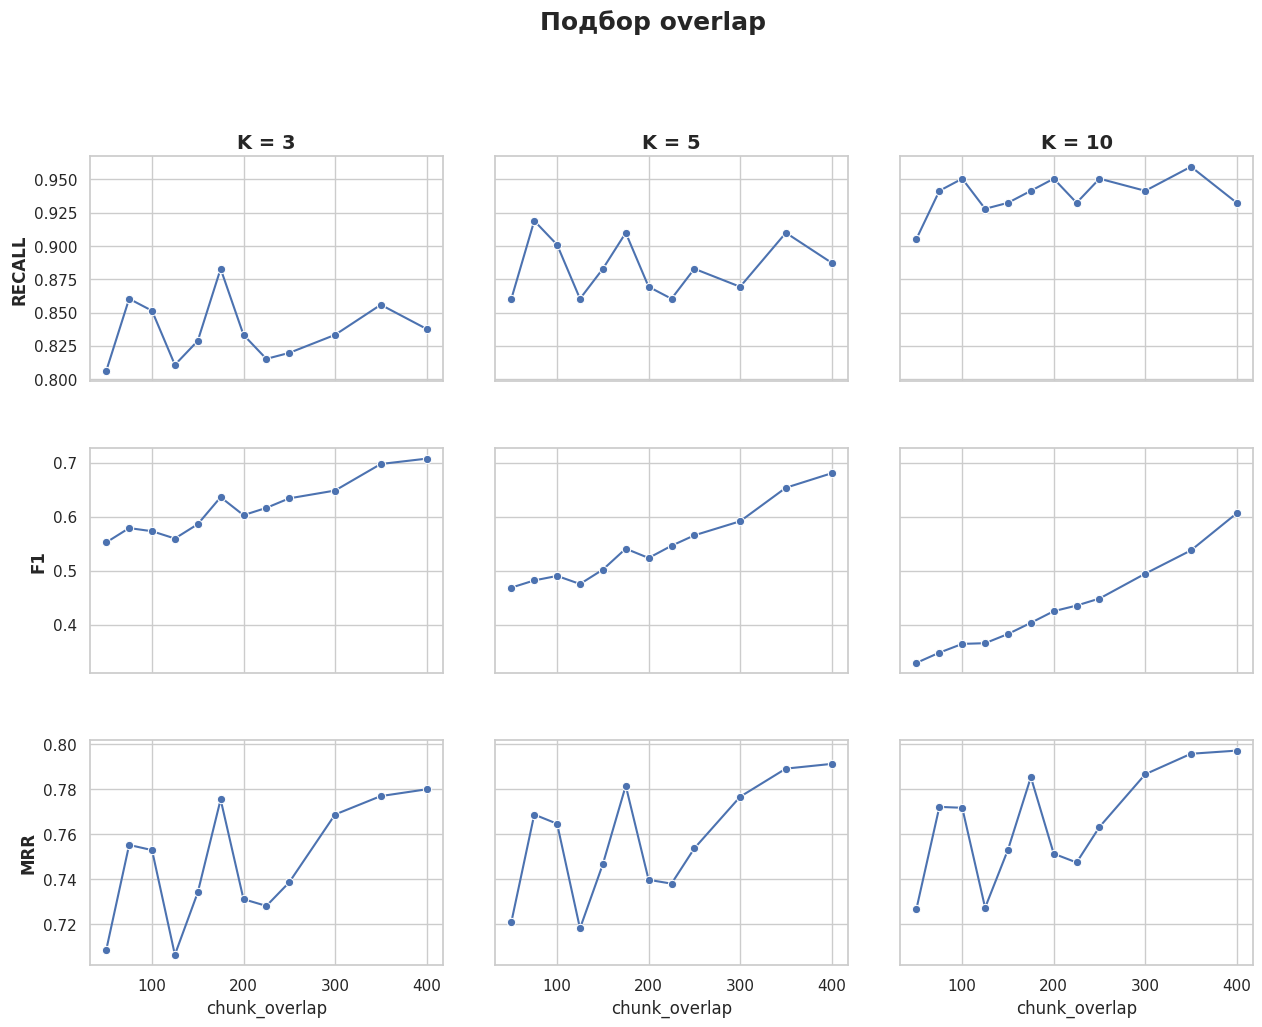

In [6]:
overlaps = [50, 75, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400]

configs_overlap = [
    RAGConfig(
        name=f"token_506_{ov}",
        chunking=ChunkingConfig(chunk_size=506, chunk_overlap=ov, splitter_type="token"),
        recreate=False
    )
    for ov in overlaps
]

results_ov = await run_experiments(configs=configs_overlap,
                                   page_mapper=page_mapper,
                                   splitter_factory=splitter_factory,
                                   eval_data=eval_data,
                                   save_csv="./new_results/overlap.csv",)

ResultsVisualizer.plot_by_variable(results_ov, x_col="chunk_overlap", title="Подбор overlap", save_path="./new_results/overlap.png", k_values=[3,5,10])

### Эксперимент 3. Сравнение сплиттеров

2026-04-24 17:33:11,672 - INFO - ============================================================
Эксперимент: token_506_175
2026-04-24 17:33:11,673 - INFO - CREATE COLLECTION
2026-04-24 17:33:11,674 - INFO - wb_token_506_175 уже существует, пропускаем
2026-04-24 17:33:12,490 - INFO -   token_506_175 | k= 1 | P=0.689 R=0.689 F1=0.689 HR=0.689 MRR=0.689
2026-04-24 17:33:12,492 - INFO -   token_506_175 | k= 2 | P=0.601 R=0.820 F1=0.674 HR=0.820 MRR=0.754
2026-04-24 17:33:12,494 - INFO -   token_506_175 | k= 3 | P=0.530 R=0.883 F1=0.636 HR=0.883 MRR=0.775
2026-04-24 17:33:12,497 - INFO -   token_506_175 | k= 5 | P=0.413 R=0.910 F1=0.541 HR=0.910 MRR=0.782
2026-04-24 17:33:12,499 - INFO -   token_506_175 | k=10 | P=0.271 R=0.941 F1=0.404 HR=0.941 MRR=0.785
2026-04-24 17:33:12,500 - INFO - ============================================================
Эксперимент: sentence_506_175
2026-04-24 17:33:12,500 - INFO - CREATE COLLECTION
2026-04-24 17:33:12,501 - INFO - wb_sentence_506_175 уже существуе

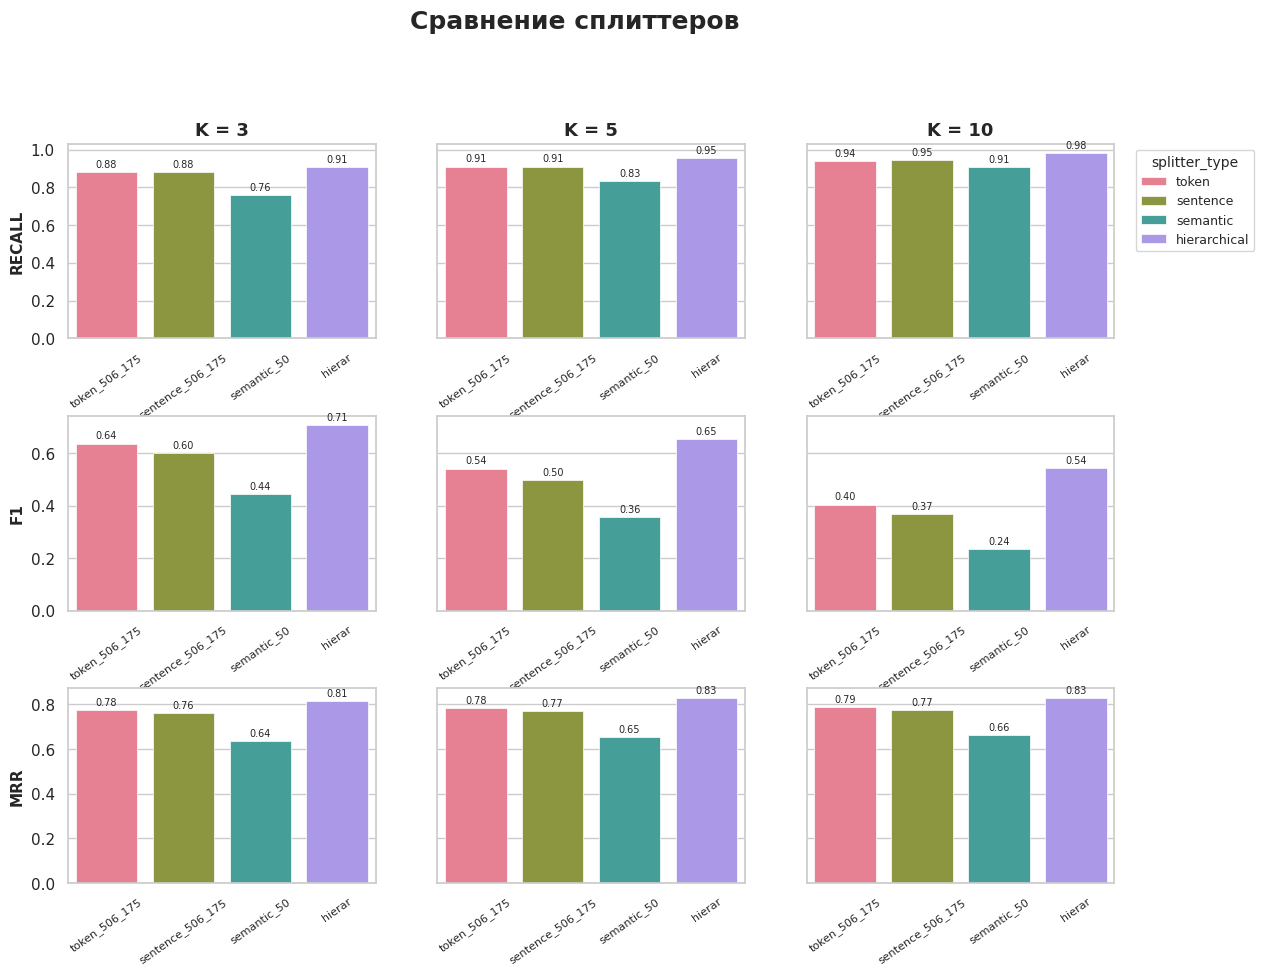

recall@k    f1@k   mrr@k
splitter_type k                           
hierarchical  3     0.9054  0.7054  0.8146
              5     0.9550  0.6544  0.8256
              10    0.9820  0.5433  0.8290
semantic      3     0.7613  0.4423  0.6351
              5     0.8333  0.3552  0.6518
              10    0.9054  0.2355  0.6618
sentence      3     0.8829  0.6009  0.7620
              5     0.9099  0.4976  0.7681
              10    0.9459  0.3671  0.7727
token         3     0.8829  0.6360  0.7755
              5     0.9099  0.5407  0.7816
              10    0.9414  0.4036  0.7854

In [8]:
configs_sp = [
    RAGConfig(name="token_506_175", chunking=ChunkingConfig(chunk_size=506, chunk_overlap=175, splitter_type="token"), recreate=False),
    RAGConfig(name="sentence_506_175", chunking=ChunkingConfig(chunk_size=506, chunk_overlap=175, splitter_type="sentence"), recreate=False),
    RAGConfig(name="semantic_50", chunking=ChunkingConfig(splitter_type="semantic", breakpoint_percentile=50), recreate=False),
    RAGConfig(name="hierar", chunking=ChunkingConfig(splitter_type="hierarchical"), recreate=False),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/splitters.csv")

# Bar chart
ResultsVisualizer.compare_categories(results_sp, title="Сравнение сплиттеров",
                                      k_values=[3,5,10], save_path="./new_results/splitters.png")
# Таблица
ResultsVisualizer.summary_table(results_sp, group_col="splitter_type", k_values=[3,5,10])

### Эксперимент 4. Сравнение разных Hierarhical сплиттеров

2026-04-24 17:40:08,486 - INFO - ============================================================
Эксперимент: hier_large
2026-04-24 17:40:08,487 - INFO - CREATE COLLECTION
2026-04-24 17:40:08,488 - INFO - wb_hier_large уже существует, пропускаем
2026-04-24 17:40:09,148 - INFO -   hier_large | k= 1 | P=0.662 R=0.662 F1=0.662 HR=0.662 MRR=0.662
2026-04-24 17:40:09,149 - INFO -   hier_large | k= 2 | P=0.610 R=0.770 F1=0.664 HR=0.770 MRR=0.716
2026-04-24 17:40:09,151 - INFO -   hier_large | k= 3 | P=0.574 R=0.833 F1=0.650 HR=0.833 MRR=0.737
2026-04-24 17:40:09,152 - INFO -   hier_large | k= 5 | P=0.477 R=0.887 F1=0.589 HR=0.887 MRR=0.750
2026-04-24 17:40:09,154 - INFO -   hier_large | k=10 | P=0.345 R=0.928 F1=0.478 HR=0.928 MRR=0.755
2026-04-24 17:40:09,155 - INFO - ============================================================
Эксперимент: hier_medium
2026-04-24 17:40:09,155 - INFO - CREATE COLLECTION
2026-04-24 17:40:09,156 - INFO - wb_hier_medium уже существует, пропускаем
2026-04-24 17:40:

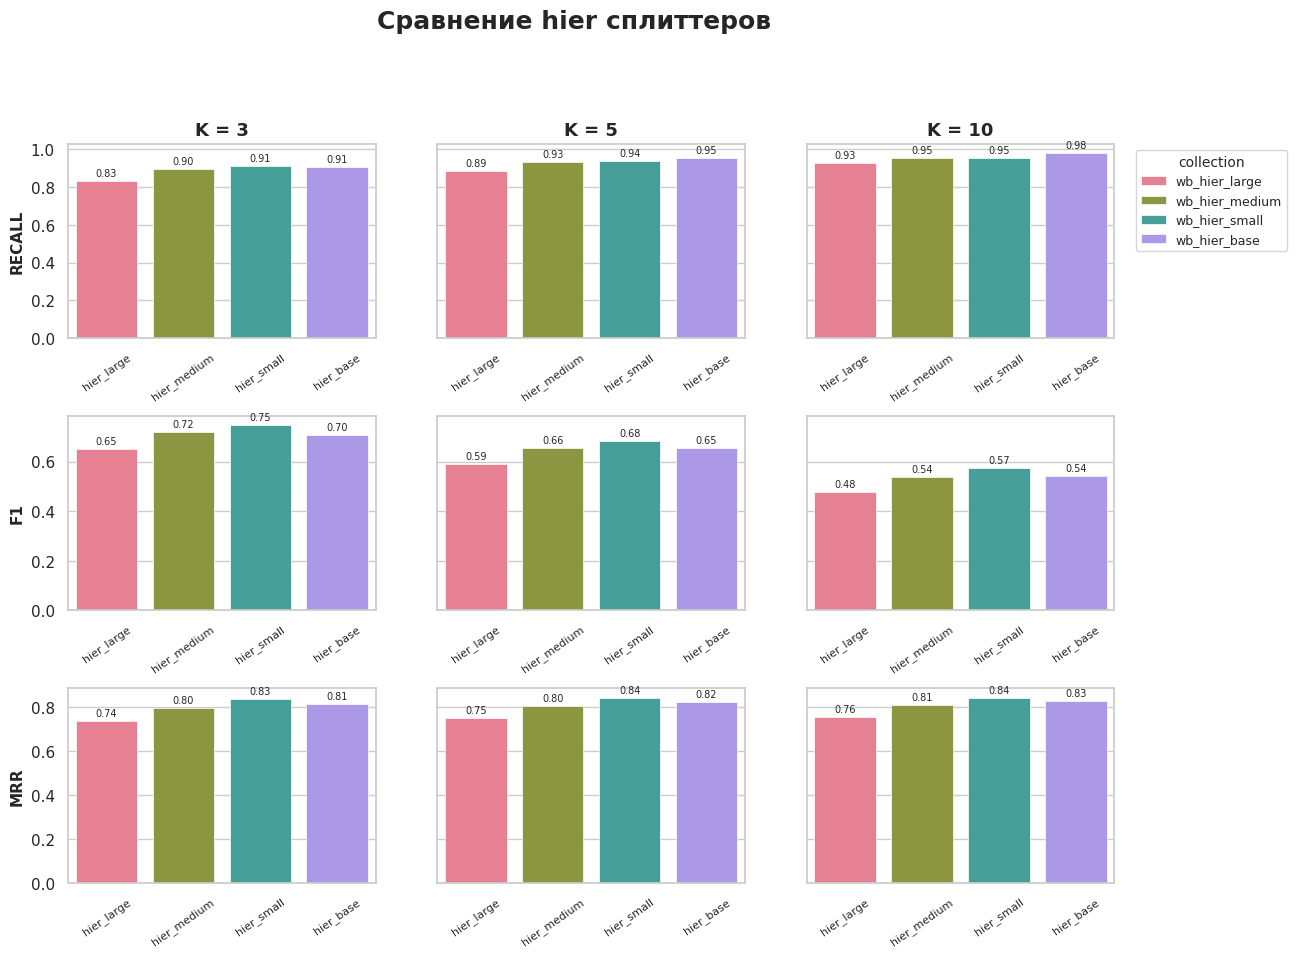

In [ ]:
configs_sp = [
    RAGConfig(name="hier_large", chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[2048, 1024, 512]), recreate=False),
    RAGConfig(name="hier_medium", chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[1024, 512, 256]), recreate=False),
    RAGConfig(name="hier_small", chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]), recreate=False),
    RAGConfig(name="hier_base", chunking=ChunkingConfig(splitter_type="hierarchical", ), recreate=False),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/hiers.csv")

# Bar chart
ResultsVisualizer.compare_categories(results_sp, title="Сравнение hier сплиттеров",
                                     category_col="collection",
                                     k_values=[3,5,10], save_path="./new_results/hiers.png")
# Таблица
# ResultsVisualizer.summary_table(results_sp, group_col="splitter_type", k_values=[1,2,3,5,10])

### Эксперимент 5. Сравнение более мелких конфигураций Hierarchical splitter

2026-04-24 17:45:55,409 - INFO - ============================================================
Эксперимент: hier_medium
2026-04-24 17:45:55,409 - INFO - CREATE COLLECTION
2026-04-24 17:45:55,411 - INFO - wb_hier_medium уже существует, пропускаем
2026-04-24 17:45:56,247 - INFO -   hier_medium | k= 1 | P=0.712 R=0.712 F1=0.712 HR=0.712 MRR=0.712
2026-04-24 17:45:56,249 - INFO -   hier_medium | k= 2 | P=0.667 R=0.833 F1=0.722 HR=0.833 MRR=0.772
2026-04-24 17:45:56,250 - INFO -   hier_medium | k= 3 | P=0.641 R=0.896 F1=0.719 HR=0.896 MRR=0.793
2026-04-24 17:45:56,252 - INFO -   hier_medium | k= 5 | P=0.545 R=0.932 F1=0.655 HR=0.932 MRR=0.802
2026-04-24 17:45:56,254 - INFO -   hier_medium | k=10 | P=0.404 R=0.955 F1=0.538 HR=0.955 MRR=0.805
2026-04-24 17:45:56,254 - INFO - ============================================================
Эксперимент: hier_small
2026-04-24 17:45:56,255 - INFO - CREATE COLLECTION
2026-04-24 17:45:56,256 - INFO - wb_hier_small уже существует, пропускаем
2026-04-24 1

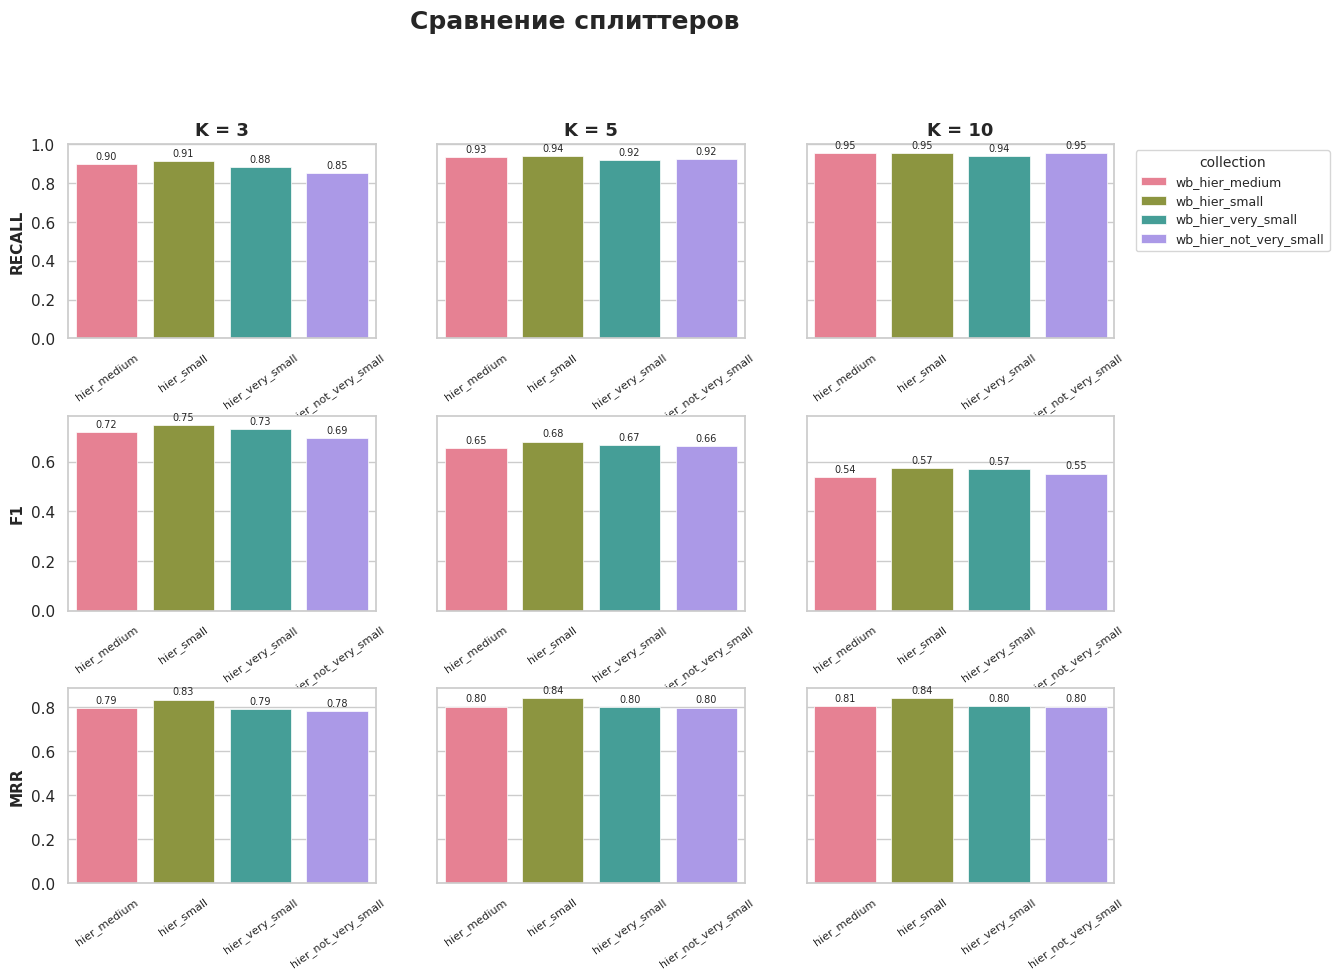

In [11]:
configs_sp = [
    RAGConfig(name="hier_medium", chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[1024, 512, 256]), recreate=False),
    RAGConfig(name="hier_small", chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]), recreate=False),
    RAGConfig(name="hier_very_small", chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[256, 128, 64]), recreate=False),
    RAGConfig(name="hier_not_very_small", chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[384, 192, 128]), recreate=False),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/hiers_small.csv")

# Bar chart
ResultsVisualizer.compare_categories(results_sp, title="Сравнение сплиттеров",
                                     category_col="collection",
                                     k_values=[3,5,10], save_path="./new_results/hiers_small.png")
# Таблица
# ResultsVisualizer.summary_table(results_sp, group_col="splitter_type", k_values=[1,2,3,5,10])

### Эксперимент 6. Embedding модель microsoft/harrier-oss-v1-0.6b

2026-04-21 20:22:16,065 - INFO - ============================================================
Эксперимент: F2LLM-v2-0.6B_hier_small
2026-04-21 20:22:16,065 - INFO - CREATE COLLECTION
Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 485.48it/s]
2026-04-21 20:22:23,183 - INFO - wb_F2LLM-v2-0.6B_hier_small: 2286 чанков (hierarchical)
2026-04-21 20:22:23,806 - INFO -   F2LLM-v2-0.6B_hier_small | k= 1 | P=0.766 R=0.766 F1=0.766 HR=0.766 MRR=0.766
2026-04-21 20:22:23,808 - INFO -   F2LLM-v2-0.6B_hier_small | k= 2 | P=0.707 R=0.869 F1=0.761 HR=0.869 MRR=0.818
2026-04-21 20:22:23,810 - INFO -   F2LLM-v2-0.6B_hier_small | k= 3 | P=0.661 R=0.919 F1=0.739 HR=0.919 MRR=0.834
2026-04-21 20:22:23,811 - INFO -   F2LLM-v2-0.6B_hier_small | k= 5 | P=0.573 R=0.960 F1=0.686 HR=0.960 MRR=0.844
2026-04-21 20:22:23,814 - INFO -   F2LLM-v2-0.6B_hier_small | k=10 | P=0.440 R=0.978 F1=0.576 HR=0.978 MRR=0.846
2026-04-21 20:22:23,815 - INFO - Сохранено: ./exp_results/F2LLM-v2-0.6B_hier_small.csv
20

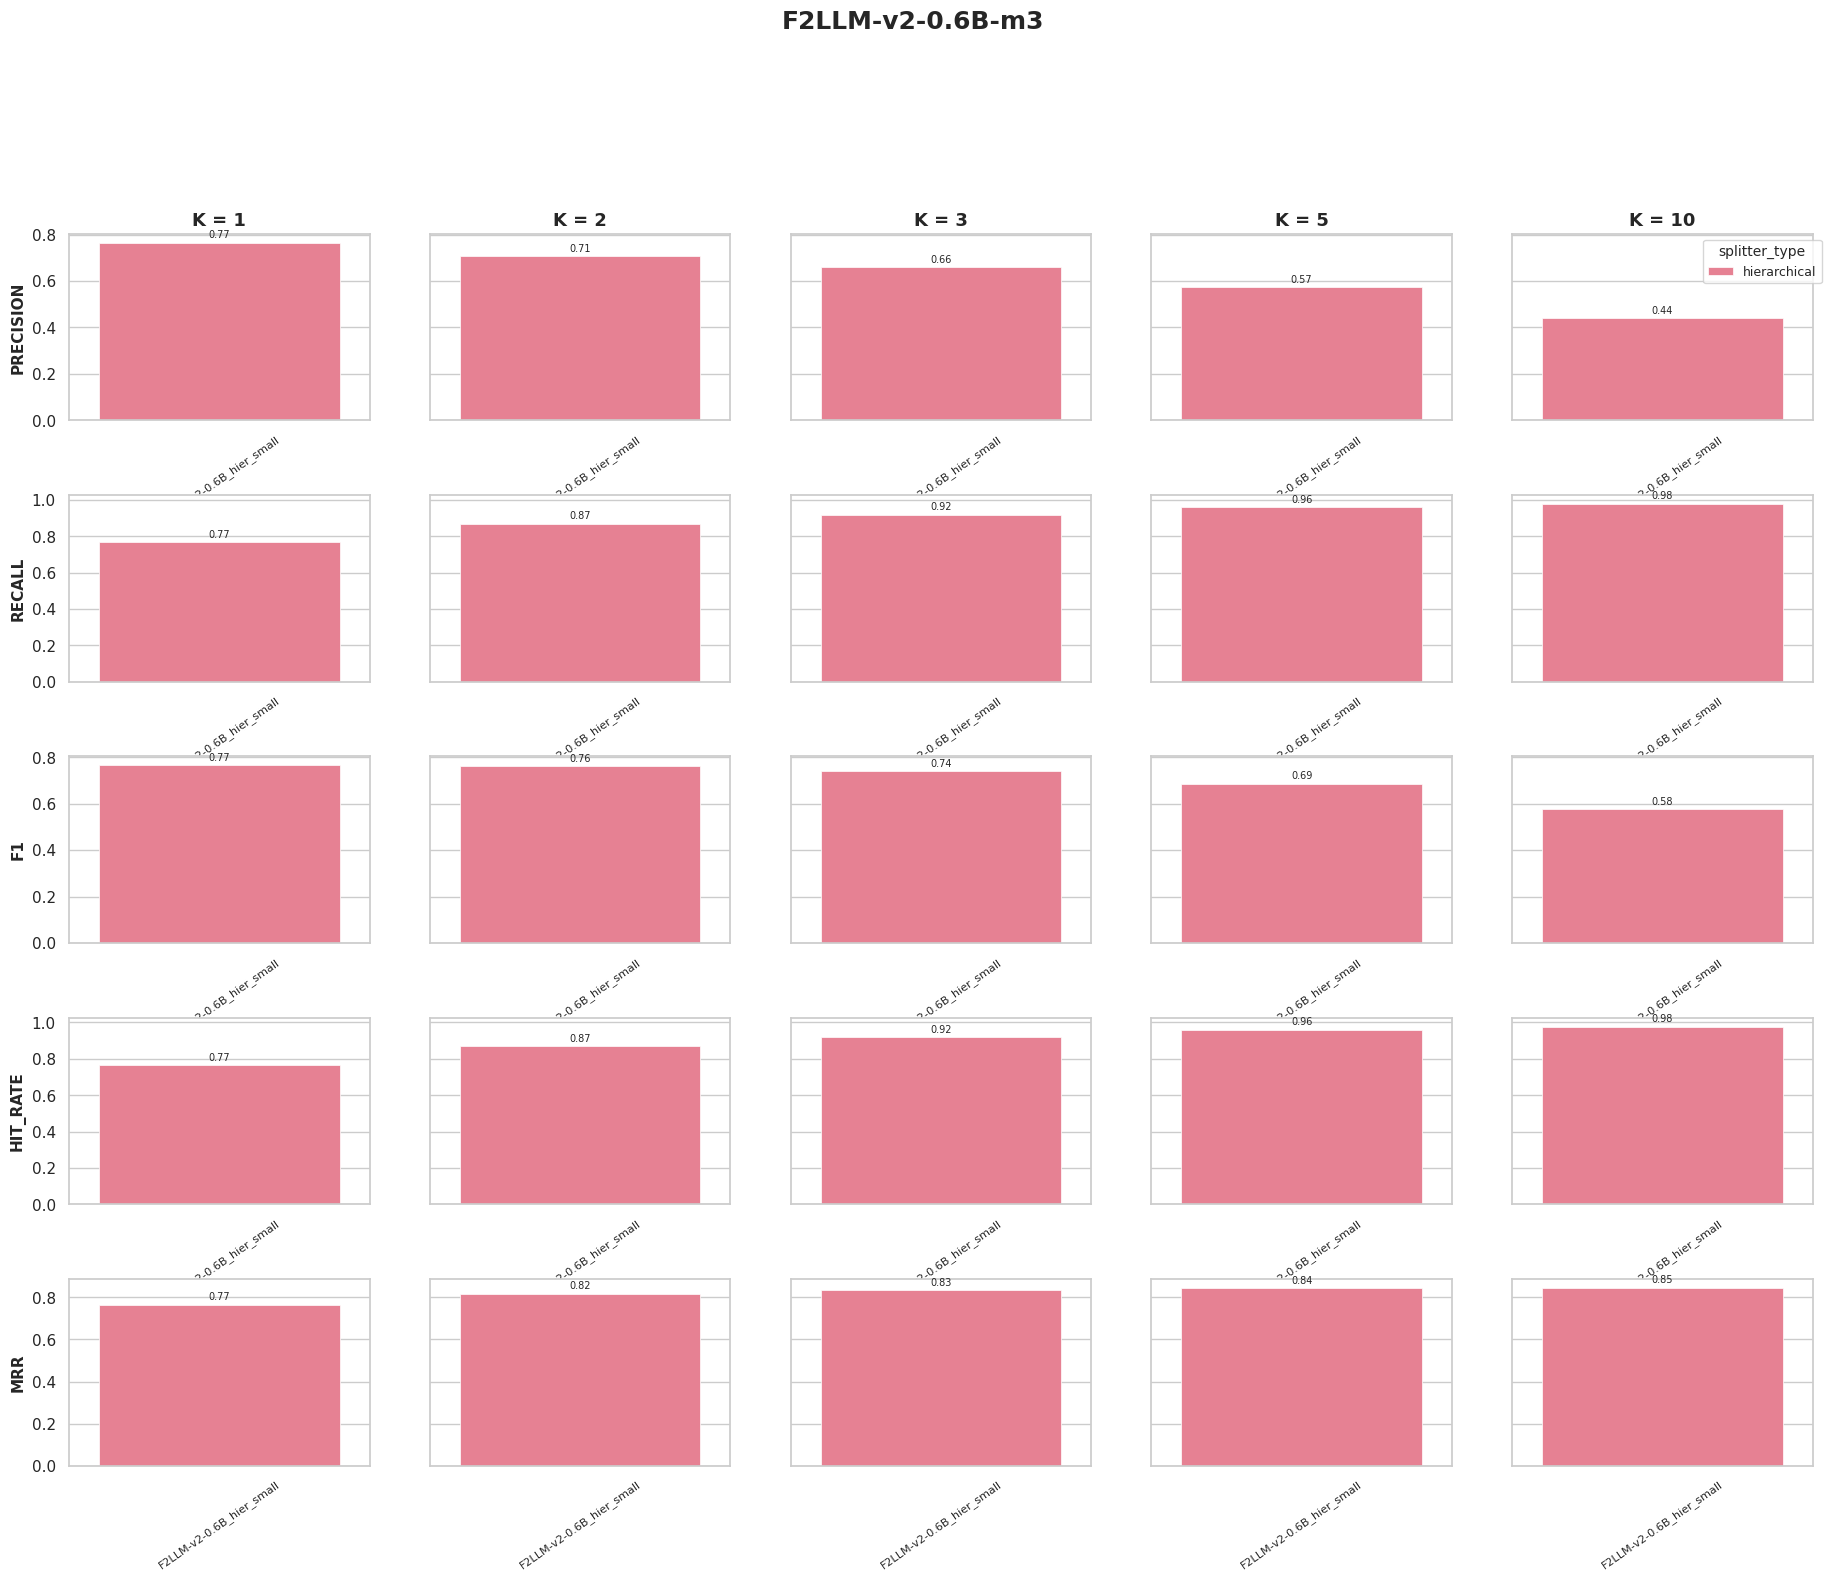

In [7]:
configs_sp = [
    RAGConfig(name="F2LLM-v2-0.6B_hier_small", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="codefuse-ai/F2LLM-v2-0.6B",
                                        api_model_name="harr-embed"),
              ),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./exp_results/F2LLM-v2-0.6B_hier_small.csv")

# Bar chart
ResultsVisualizer.compare_categories(results_sp, title="F2LLM-v2-0.6B-m3",
                                      k_values=[1,2,3,5,10], save_path="./exp_results/F2LLM-v2-0.6B_hier_small.png")

### Эксперимент. Embedding модель jinaai/jina-embeddings-v3

2026-04-22 17:53:09,310 - INFO - ============================================================
Эксперимент: jina-embeddings-v3_hier_small
2026-04-22 17:53:09,310 - INFO - CREATE COLLECTION


Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 659.30it/s]
2026-04-22 17:53:22,781 - INFO - wb_jina-embeddings-v3_hier_small: 2286 чанков (hierarchical)
2026-04-22 17:53:23,659 - INFO -   jina-embeddings-v3_hier_small | k= 1 | P=0.707 R=0.707 F1=0.707 HR=0.707 MRR=0.707
2026-04-22 17:53:23,660 - INFO -   jina-embeddings-v3_hier_small | k= 2 | P=0.680 R=0.838 F1=0.733 HR=0.838 MRR=0.772
2026-04-22 17:53:23,662 - INFO -   jina-embeddings-v3_hier_small | k= 3 | P=0.640 R=0.887 F1=0.716 HR=0.887 MRR=0.789
2026-04-22 17:53:23,663 - INFO -   jina-embeddings-v3_hier_small | k= 5 | P=0.529 R=0.914 F1=0.641 HR=0.914 MRR=0.795
2026-04-22 17:53:23,665 - INFO -   jina-embeddings-v3_hier_small | k=10 | P=0.414 R=0.946 F1=0.546 HR=0.946 MRR=0.799
2026-04-22 17:53:23,668 - INFO - Сохранено: ./exp_results/jina-embeddings-v3_hier_small.csv
2026-04-22 17:53:24,791 - INFO - График: ./exp_results/jina-embeddings-v3_hier_small.png


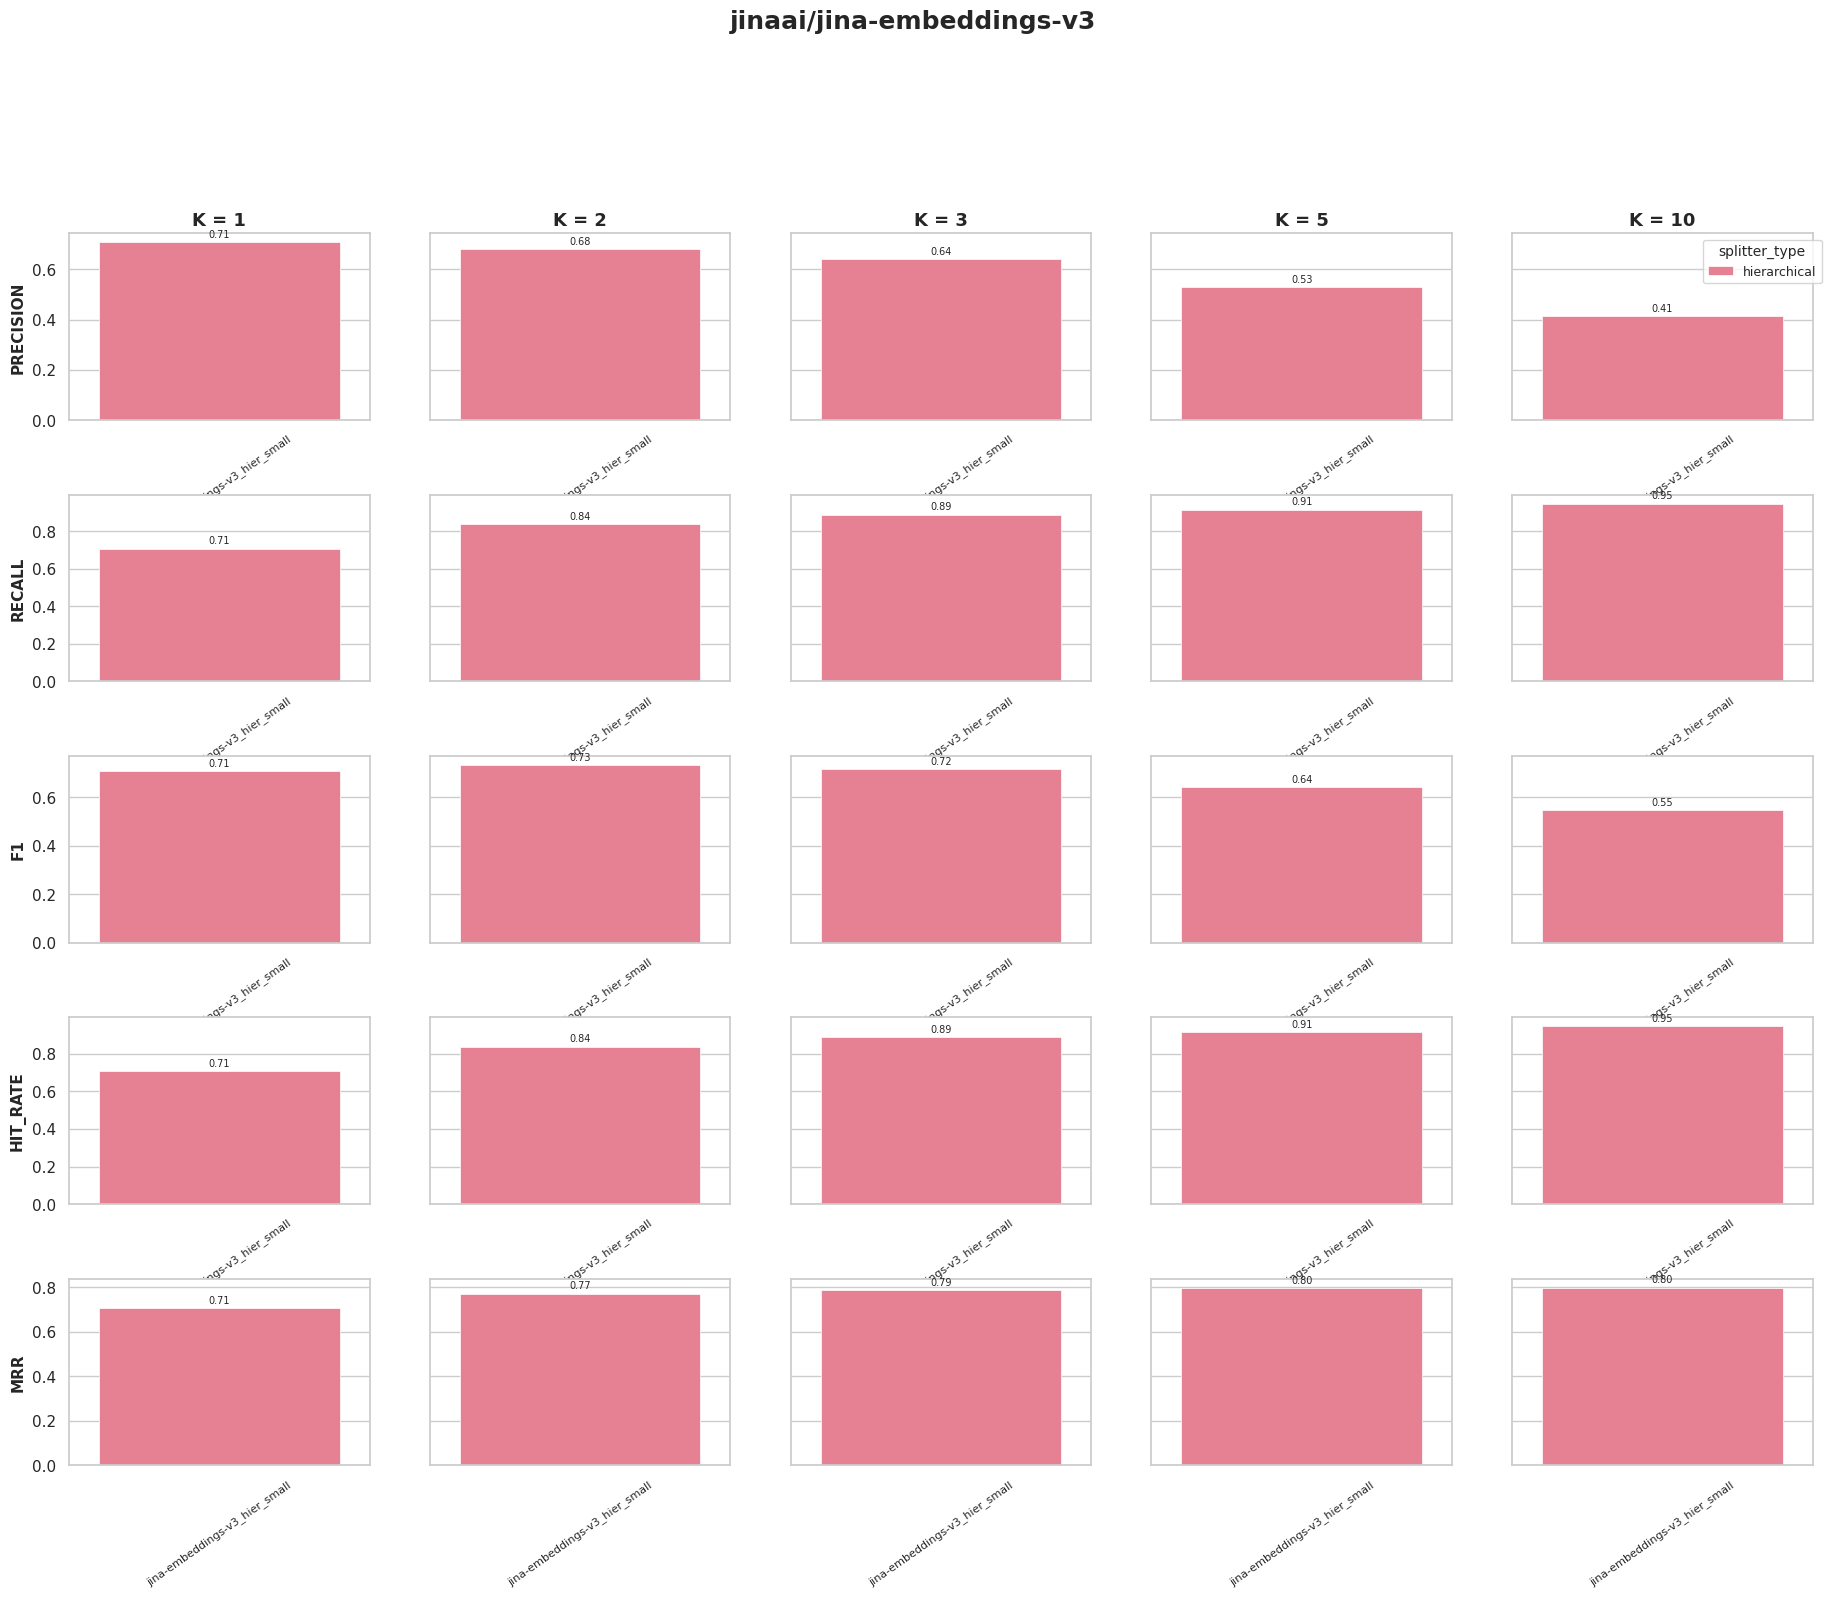

In [7]:
configs_sp = [
    RAGConfig(name="jina-embeddings-v3_hier_small", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="jinaai/jina-embeddings-v3",
                                        api_model_name="harr-embed"),
              ),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./exp_results/jina-embeddings-v3_hier_small.csv")

# Bar chart
ResultsVisualizer.compare_categories(results_sp, title="jinaai/jina-embeddings-v3",
                                      k_values=[1,2,3,5,10], save_path="./exp_results/jina-embeddings-v3_hier_small.png")

### Эксперимент. Embedding модель jinaai/jina-embeddings-v3

In [ ]:
configs_sp = [
    RAGConfig(name="jina-embeddings-v3_hier_small", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="jinaai/jina-embeddings-v3",
                                        api_model_name="harr-embed"),
              ),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./exp_results/jina-embeddings-v3_hier_small.csv")

# Bar chart
ResultsVisualizer.compare_categories(results_sp, title="jinaai/jina-embeddings-v3",
                                      k_values=[1,2,3,5,10], save_path="./exp_results/jina-embeddings-v3_hier_small.png")

### Эксперимент. Embedding модель qwen3-0.6b

In [13]:
configs_sp = [
    RAGConfig(name="qwen3-embedding-0.6b_hier_small", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="Qwen/Qwen3-Embedding-0.6B",
                                        api_model_name="qwen3-embed"), recreate=False,
              ),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/qwen3-0.6b_hier_small.csv")

# Bar chart
# ResultsVisualizer.compare_categories(results_sp, title="Qwen/Qwen3-Embedding-0.6B",
#                                       k_values=[3,5,10], save_path="./new_results/qwen3-0.6b_hier_small.png")

2026-04-24 18:07:38,176 - INFO - ============================================================
Эксперимент: qwen3-embedding-0.6b_hier_small
2026-04-24 18:07:38,177 - INFO - CREATE COLLECTION
2026-04-24 18:07:38,180 - INFO - wb_qwen3-embedding-0.6b_hier_small уже существует, пропускаем
2026-04-24 18:07:38,816 - INFO -   qwen3-embedding-0.6b_hier_small | k= 1 | P=0.766 R=0.766 F1=0.766 HR=0.766 MRR=0.766
2026-04-24 18:07:38,817 - INFO -   qwen3-embedding-0.6b_hier_small | k= 2 | P=0.723 R=0.878 F1=0.775 HR=0.878 MRR=0.822
2026-04-24 18:07:38,819 - INFO -   qwen3-embedding-0.6b_hier_small | k= 3 | P=0.667 R=0.914 F1=0.746 HR=0.914 MRR=0.834
2026-04-24 18:07:38,820 - INFO -   qwen3-embedding-0.6b_hier_small | k= 5 | P=0.572 R=0.941 F1=0.682 HR=0.941 MRR=0.841
2026-04-24 18:07:38,823 - INFO -   qwen3-embedding-0.6b_hier_small | k=10 | P=0.438 R=0.955 F1=0.573 HR=0.955 MRR=0.843
2026-04-24 18:07:38,824 - INFO - Сохранено: ./new_results/qwen3-0.6b_hier_small.csv


new experiment

### Эксперимент. Модель intfloat/multilingual-e5-large-instruct

In [17]:
Settings.embed_model = None

Embeddings have been explicitly disabled. Using MockEmbedding.


In [3]:
configs_sp = [
    RAGConfig(name="multilingual-e5-large-instruct_hier_small", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="intfloat/multilingual-e5-large-instruct",
                                        api_model_name="harr-embed"),
              ),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/multilingual-e5-large-instruct_hier_small.csv")

2026-04-25 11:06:31,451 - INFO - ============================================================
Эксперимент: multilingual-e5-large-instruct_hier_small
2026-04-25 11:06:31,451 - INFO - CREATE COLLECTION
2026-04-25 11:06:31,615 - INFO - Embedding: intfloat/multilingual-e5-large-instruct @ http://localhost:8081/v1
Generating embeddings: 100%|██████████| 238/238 [00:00<00:00, 693.99it/s]
2026-04-25 11:06:45,239 - INFO - wb_multilingual-e5-large-instruct_hier_small: 2286 чанков (hierarchical)
2026-04-25 11:06:45,883 - INFO -   multilingual-e5-large-instruct_hier_small | k= 1 | P=0.748 R=0.748 F1=0.748 HR=0.748 MRR=0.748
2026-04-25 11:06:45,884 - INFO -   multilingual-e5-large-instruct_hier_small | k= 2 | P=0.696 R=0.851 F1=0.748 HR=0.851 MRR=0.799
2026-04-25 11:06:45,885 - INFO -   multilingual-e5-large-instruct_hier_small | k= 3 | P=0.638 R=0.892 F1=0.723 HR=0.892 MRR=0.813
2026-04-25 11:06:45,887 - INFO -   multilingual-e5-large-instruct_hier_small | k= 5 | P=0.568 R=0.937 F1=0.680 HR=0.937

2026-04-25 11:06:53,543 - INFO - График: ./new_results/multilingual-e5-large-instruct_hier_small.png


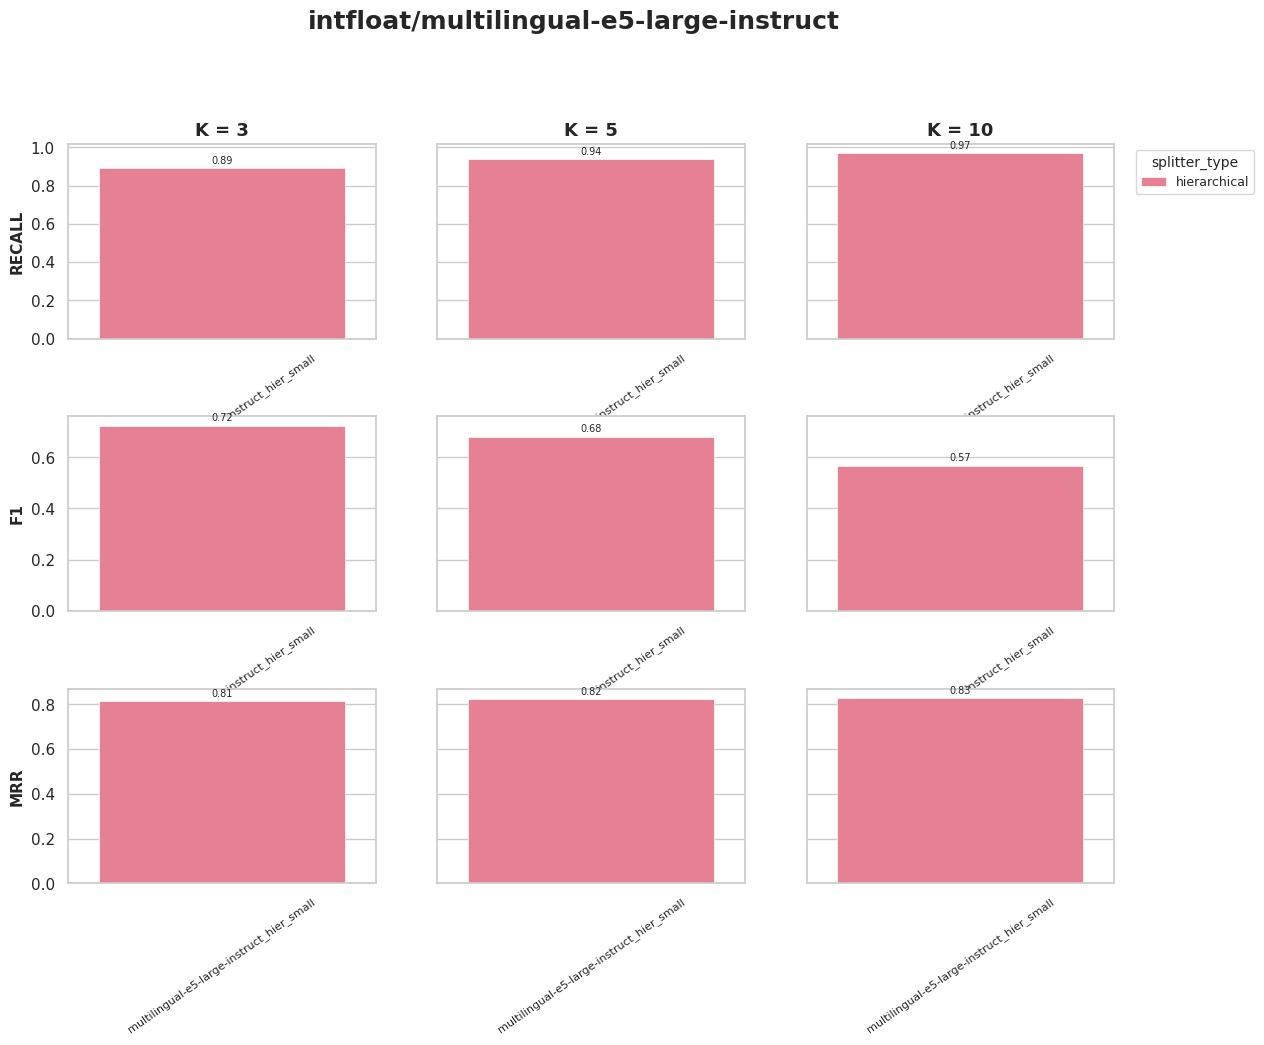

In [4]:
ResultsVisualizer.compare_categories(results_sp, title="intfloat/multilingual-e5-large-instruct",
                                      k_values=[3,5,10], save_path="./new_results/multilingual-e5-large-instruct_hier_small.png")

### Эксперимент. Сравнение embed моделей

In [5]:
df_bge = pd.read_csv("./exp_results/bge_m3_hier_small.csv")
df_f2llm = pd.read_csv("./exp_results/F2LLM-v2-0.6B_hier_small.csv")
df_jina = pd.read_csv("./exp_results/jina-embeddings-v3_hier_small.csv")
df_qwen3 = pd.read_csv("./new_results/qwen3-0.6b_hier_small.csv")
df_e5 = pd.read_csv("./new_results/multilingual-e5-large-instruct_hier_small.csv")

2026-04-25 11:31:15,720 - INFO - График: ./new_results/embed_models.png


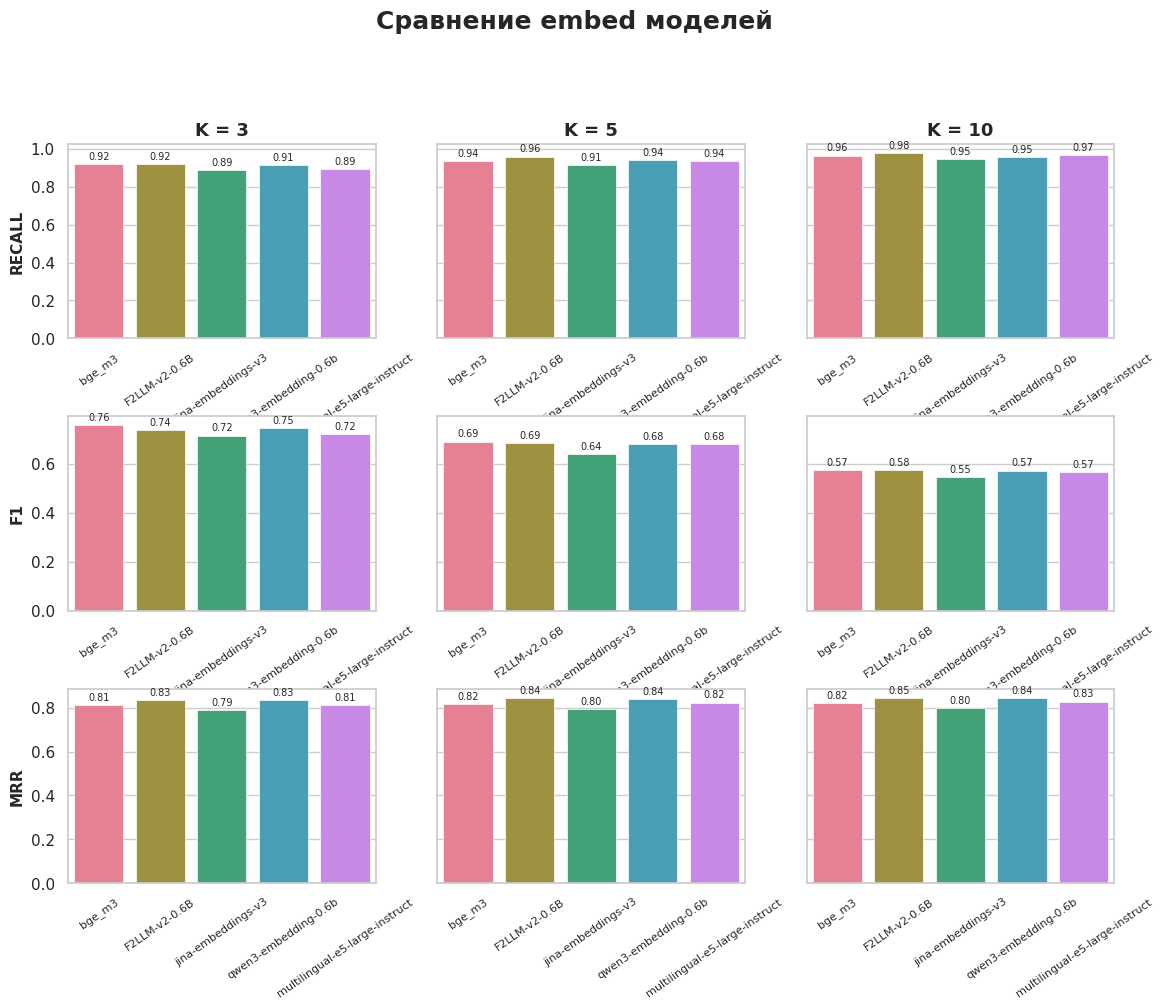

In [ ]:
df_all_models = pd.concat([df_bge, df_f2llm, df_jina, df_qwen3, df_e5])
df_all_models["experiment"] = df_all_models["experiment"].str.replace("_hier_small", "")
ResultsVisualizer.compare_categories(df_all_models,
                                     title="Сравнение embed моделей",
                                     category_col="experiment",
                                     k_values=[3,5,10],
                                     save_path="./new_results/embed_models.png")

### Хорошо. Допустим выбрали модель F2LLM-v2-0.6B как наилучшую, хотя отрыв минимальный. 
Прикручиваем теперь reranker и смотрим на метрики

In [ ]:
configs_sp = [
    RAGConfig(name="F2LLM-v2-0.6B-rerank", 
              chunking=ChunkingConfig(splitter_type="hierarchical", hierarchy_sizes=[512, 256, 128]),
              embedding=EmbeddingConfig(model_name="codefuse-ai/F2LLM-v2-0.6B",
                                        api_model_name="harr-embed"),
              retrieval=RetrievalConfig()
              ),
]
results_sp = await run_experiments(configs_sp, page_mapper, splitter_factory, eval_data,
                                   save_csv="./new_results/multilingual-e5-large-instruct_hier_small.csv")